In [1]:
!pip install -q \
    "tensorflow==2.20.0" \
    "tensorflow-text==2.20.1" \
    "keras==3.15.1" \
    "keras-cv==0.9.0"

In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import sys
import tensorflow as tf
import keras
import keras_cv

print("Environment")
print("-" * 40)
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

print("\nGPU")
print("-" * 40)
print(tf.config.list_physical_devices("GPU"))

print("\nYOLOv8 API")
print("-" * 40)
print("YOLOV8Backbone:", hasattr(keras_cv.models, "YOLOV8Backbone"))
print("YOLOV8Detector:", hasattr(keras_cv.models, "YOLOV8Detector"))

Environment
----------------------------------------
Python: 3.13.15
TensorFlow: 2.20.0
Keras: 3.15.1
KerasCV: 0.9.0

GPU
----------------------------------------
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

YOLOv8 API
----------------------------------------
YOLOV8Backbone: True
YOLOV8Detector: True


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/NutriVision")
ZIP_PATH = DRIVE_ROOT / "foodseg103_yolo.zip"

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP path:", ZIP_PATH)

ZIP exists: True
ZIP path: /content/drive/MyDrive/NutriVision/foodseg103_yolo.zip


In [57]:
import zipfile

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DRIVE_ROOT)

print("Dataset extraction completed.")

Dataset extraction completed.


In [58]:
DATASET_ROOT = DRIVE_ROOT / "foodseg103_yolo"

print("Dataset root exists:", DATASET_ROOT.exists())
print()

print("Images directory:", (DATASET_ROOT / "images").exists())
print("Train images directory:", (DATASET_ROOT / "images" / "train").exists())
print("Validation images directory:", (DATASET_ROOT / "images" / "val").exists())

print()

print("Labels directory:", (DATASET_ROOT / "labels").exists())
print("Train labels directory:", (DATASET_ROOT / "labels" / "train").exists())
print("Validation labels directory:", (DATASET_ROOT / "labels" / "val").exists())

print()

print("data.yaml:", (DATASET_ROOT / "data.yaml").exists())

Dataset root exists: True

Images directory: True
Train images directory: True
Validation images directory: True

Labels directory: True
Train labels directory: True
Validation labels directory: True

data.yaml: True


In [59]:
TRAIN_IMAGES = DATASET_ROOT / "images" / "train"
TRAIN_LABELS = DATASET_ROOT / "labels" / "train"

VAL_IMAGES = DATASET_ROOT / "images" / "val"
VAL_LABELS = DATASET_ROOT / "labels" / "val"

train_images = list(TRAIN_IMAGES.glob("*.jpg"))
train_labels = list(TRAIN_LABELS.glob("*.txt"))

val_images = list(VAL_IMAGES.glob("*.jpg"))
val_labels = list(VAL_LABELS.glob("*.txt"))

print("TRAIN")
print("Images:", len(train_images))
print("Labels:", len(train_labels))

print("\nVALIDATION")
print("Images:", len(val_images))
print("Labels:", len(val_labels))

print("\nDATA.YAML exists:", (DATASET_ROOT / "data.yaml").exists())

assert len(train_images) == 4979
assert len(train_labels) == 4979
assert len(val_images) == 2135
assert len(val_labels) == 2135
assert (DATASET_ROOT / "data.yaml").exists()

print("\nDATASET VERIFICATION: PASSED")

TRAIN
Images: 4979
Labels: 4979

VALIDATION
Images: 2135
Labels: 2135

DATA.YAML exists: True

DATASET VERIFICATION: PASSED


In [60]:
import yaml

DATA_YAML = DATASET_ROOT / "data.yaml"

with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

class_names = data_config["names"]

print("Number of classes:", len(class_names))
print("First 10 classes:")

for class_id, name in list(enumerate(class_names))[:10]:
    print(f"{class_id}: {name}")

Number of classes: 103
First 10 classes:
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9


In [61]:
from PIL import Image
import numpy as np

image_path = sorted(TRAIN_IMAGES.glob("*.jpg"))[0]
label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

image = Image.open(image_path).convert("RGB")
image_array = np.array(image)

print("Image:", image_path.name)
print("Image size:", image.size)
print("Label:", label_path.name)

with open(label_path, "r") as f:
    label_lines = [line.strip() for line in f if line.strip()]

print("Number of annotations:", len(label_lines))
print("\nFirst annotation:")
print(label_lines[0])

Image: 00000.jpg
Image size: (512, 384)
Label: 00000.txt
Number of annotations: 3

First annotation:
47 0.254883 0.661458 0.509766 0.671875


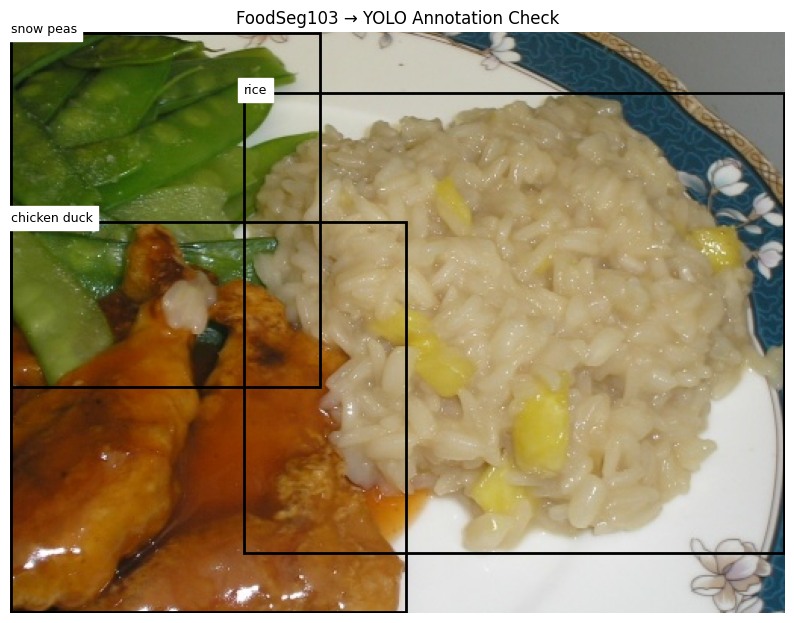

In [62]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(image_array)

image_width, image_height = image.size

for line in label_lines:
    class_id, x_center, y_center, box_width, box_height = map(
        float, line.split()
    )

    # YOLO normalized coordinates → pixel coordinates
    x_center *= image_width
    y_center *= image_height
    box_width *= image_width
    box_height *= image_height

    x_min = x_center - box_width / 2
    y_min = y_center - box_height / 2

    rectangle = patches.Rectangle(
        (x_min, y_min),
        box_width,
        box_height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        x_min,
        y_min,
        class_names[int(class_id)],
        fontsize=9,
        backgroundcolor="white"
    )

ax.set_title("FoodSeg103 → YOLO Annotation Check")
ax.axis("off")
plt.show()

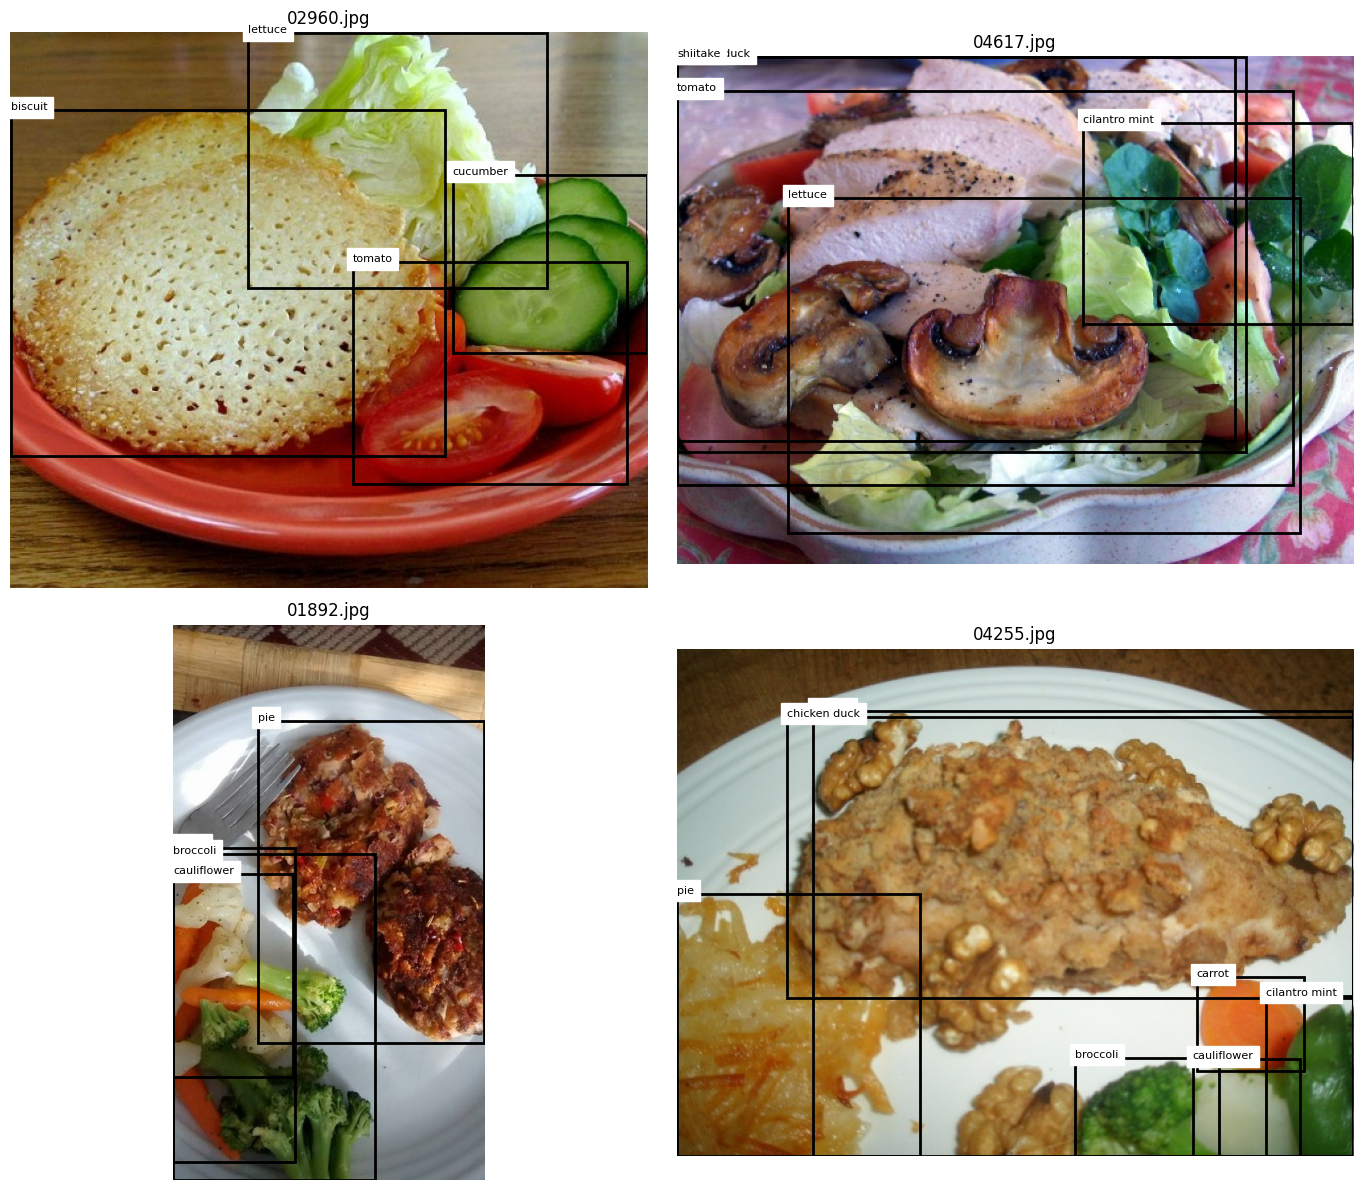

In [63]:
import random

sample_paths = random.sample(train_images, 4)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, image_path in zip(axes, sample_paths):

    label_path = TRAIN_LABELS / f"{image_path.stem}.txt"

    img = Image.open(image_path).convert("RGB")
    img_width, img_height = img.size

    ax.imshow(img)

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        class_id, x_center, y_center, box_width, box_height = map(
            float, line.split()
        )

        x_center *= img_width
        y_center *= img_height
        box_width *= img_width
        box_height *= img_height

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2

        rect = patches.Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            x_min,
            y_min,
            class_names[int(class_id)],
            fontsize=8,
            backgroundcolor="white"
        )

    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [64]:
def validate_yolo_labels(label_dir, num_classes=103):
    label_files = list(label_dir.glob("*.txt"))

    total_annotations = 0
    errors = []

    for label_file in label_files:
        with open(label_file, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line_number, line in enumerate(lines, start=1):
            values = line.split()

            if len(values) != 5:
                errors.append(
                    f"{label_file.name}: line {line_number} does not have 5 values"
                )
                continue

            class_id, x, y, w, h = map(float, values)

            if not 0 <= int(class_id) < num_classes:
                errors.append(
                    f"{label_file.name}: invalid class ID {class_id}"
                )

            if not all(0 <= value <= 1 for value in [x, y, w, h]):
                errors.append(
                    f"{label_file.name}: coordinates outside [0, 1]"
                )

            if w <= 0 or h <= 0:
                errors.append(
                    f"{label_file.name}: invalid box size"
                )

            total_annotations += 1

    return len(label_files), total_annotations, errors


label_count, annotation_count, errors = validate_yolo_labels(
    TRAIN_LABELS
)

print("Training label files:", label_count)
print("Training annotations:", annotation_count)
print("Errors:", len(errors))

if errors:
    print("\nFirst errors:")
    for error in errors[:10]:
        print(error)
else:
    print("\nANNOTATION SANITY CHECK: PASSED")

Training label files: 4979
Training annotations: 18306
Errors: 0

ANNOTATION SANITY CHECK: PASSED


In [65]:
IMAGE_SIZE = 640
BATCH_SIZE = 4
NUM_CLASSES = 103

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

Image size: 640
Batch size: 4
Number of classes: 103


In [66]:
from PIL import Image
import numpy as np
import tensorflow as tf

def load_detection_sample(image_path, label_dir):
    image_path = Path(image_path)
    label_path = Path(label_dir) / f"{image_path.stem}.txt"

    # Load and resize image.
    image = Image.open(image_path).convert("RGB")
    image = image.resize((IMAGE_SIZE, IMAGE_SIZE))

    image = np.asarray(image, dtype=np.float32)

    # Read YOLO annotations.
    boxes = []
    classes = []

    with open(label_path, "r") as f:
        for line in f:
            values = line.strip().split()

            if not values:
                continue

            class_id, x_center, y_center, width, height = map(float, values)

            # YOLO normalized xywh -> pixel xyxy
            x1 = (x_center - width / 2) * IMAGE_SIZE
            y1 = (y_center - height / 2) * IMAGE_SIZE
            x2 = (x_center + width / 2) * IMAGE_SIZE
            y2 = (y_center + height / 2) * IMAGE_SIZE

            boxes.append([x1, y1, x2, y2])
            classes.append(class_id)

    return (
        image,
        np.asarray(boxes, dtype=np.float32),
        np.asarray(classes, dtype=np.float32),
    )


sample_image, sample_boxes, sample_classes = load_detection_sample(
    train_images[0],
    TRAIN_LABELS,
)

print("Image shape:", sample_image.shape)
print("Boxes shape:", sample_boxes.shape)
print("Classes shape:", sample_classes.shape)
print("First box:", sample_boxes[0])
print("First class:", sample_classes[0])

Image shape: (640, 640, 3)
Boxes shape: (3, 4)
Classes shape: (3,)
First box: [  0.      208.33311 326.25024 638.3331 ]
First class: 47.0


In [67]:
print("Box coordinate range:")
print("Minimum:", sample_boxes.min())
print("Maximum:", sample_boxes.max())

print("\nClass ID range:")
print("Minimum:", sample_classes.min())
print("Maximum:", sample_classes.max())

assert sample_boxes.shape[1] == 4
assert np.all(sample_boxes[:, 0] >= 0)
assert np.all(sample_boxes[:, 1] >= 0)
assert np.all(sample_boxes[:, 2] <= IMAGE_SIZE)
assert np.all(sample_boxes[:, 3] <= IMAGE_SIZE)
assert np.all(sample_boxes[:, 2] > sample_boxes[:, 0])
assert np.all(sample_boxes[:, 3] > sample_boxes[:, 1])
assert np.all(sample_classes >= 0)
assert np.all(sample_classes < NUM_CLASSES)

print("\nBOX CONVERSION: PASSED")

Box coordinate range:
Minimum: 0.0
Maximum: 638.75006

Class ID range:
Minimum: 47.0
Maximum: 89.0

BOX CONVERSION: PASSED


In [68]:
def dataset_generator(image_paths, label_dir, shuffle=False):
    paths = list(image_paths)

    if shuffle:
        rng = np.random.default_rng(42)
        rng.shuffle(paths)

    for image_path in paths:
        image, boxes, classes = load_detection_sample(
            image_path,
            label_dir,
        )

        yield {
            "images": image,
            "bounding_boxes": {
                "boxes": boxes,
                "classes": classes,
            },
        }


output_signature = {
    "images": tf.TensorSpec(
        shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        dtype=tf.float32,
    ),
    "bounding_boxes": {
        "boxes": tf.TensorSpec(
            shape=(None, 4),
            dtype=tf.float32,
        ),
        "classes": tf.TensorSpec(
            shape=(None,),
            dtype=tf.float32,
        ),
    },
}


train_ds = tf.data.Dataset.from_generator(
    lambda: dataset_generator(
        train_images,
        TRAIN_LABELS,
        shuffle=True,
    ),
    output_signature=output_signature,
)

val_ds = tf.data.Dataset.from_generator(
    lambda: dataset_generator(
        val_images,
        VAL_LABELS,
        shuffle=False,
    ),
    output_signature=output_signature,
)

train_ds = train_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)
val_ds = val_ds.ragged_batch(BATCH_SIZE, drop_remainder=True)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [69]:
batch = next(iter(train_ds))

images = batch["images"]
bounding_boxes = batch["bounding_boxes"]

print("Images shape:", images.shape)
print("Boxes shape:", bounding_boxes["boxes"].shape)
print("Classes shape:", bounding_boxes["classes"].shape)

print("\nImage dtype:", images.dtype)
print("Boxes dtype:", bounding_boxes["boxes"].dtype)
print("Classes dtype:", bounding_boxes["classes"].dtype)

Images shape: (4, 640, 640, 3)
Boxes shape: (4, None, 4)
Classes shape: (4, None)

Image dtype: <dtype: 'float32'>
Boxes dtype: <dtype: 'float32'>
Classes dtype: <dtype: 'float32'>


In [70]:
def prepare_for_model(sample):
    images = sample["images"] / 255.0
    bounding_boxes = sample["bounding_boxes"]

    return images, bounding_boxes


train_model_ds = train_ds.map(
    prepare_for_model,
    num_parallel_calls=tf.data.AUTOTUNE,
)

val_model_ds = val_ds.map(
    prepare_for_model,
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_model_ds = train_model_ds.prefetch(tf.data.AUTOTUNE)
val_model_ds = val_model_ds.prefetch(tf.data.AUTOTUNE)

print("Model input pipeline ready.")

Model input pipeline ready.


In [71]:
backbone = keras_cv.models.YOLOV8Backbone.from_preset(
    "yolo_v8_s_backbone_coco"
)

print("YOLOv8-S COCO-pretrained backbone loaded.")

100%|██████████| 646/646 [00:00<00:00, 441kB/s]


YOLOv8-S COCO-pretrained backbone loaded.


In [72]:
detector = keras_cv.models.YOLOV8Detector(
    num_classes=NUM_CLASSES,
    bounding_box_format="xyxy",
    backbone=backbone,
    fpn_depth=1,
)

print("YOLOv8 detector created.")
print("Number of classes:", NUM_CLASSES)
print("Bounding-box format: xyxy")

YOLOv8 detector created.
Number of classes: 103
Bounding-box format: xyxy


In [73]:
detector.summary()

Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │  5,089,760 │ input_layer_1[0]… │
│ (Functional)        │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 512)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 512)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 768)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │    196,608 │ concatenate_5[0]… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │      1,024 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 128),       │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 128)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │    147,456 │ pa_fpn_p4p5_pre_

 Total params: 12,836,949 (48.97 MB)

 Trainable params: 12,815,381 (48.89 MB)

 Non-trainable params: 21,568 (84.25 KB)

In [74]:
detector.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    classification_loss="binary_crossentropy",
    box_loss="ciou",
)

print("YOLOv8 baseline compiled successfully.")

YOLOv8 baseline compiled successfully.


In [75]:
sample_images, sample_targets = next(iter(train_model_ds.take(1)))

print("Input batch:")
print("Images:", sample_images.shape)
print("Boxes:", sample_targets["boxes"].shape)
print("Classes:", sample_targets["classes"].shape)

raw_output = detector(sample_images, training=False)

print("\nForward pass: PASSED")
print("Output type:", type(raw_output))

Input batch:
Images: (4, 640, 640, 3)
Boxes: (4, None, 4)
Classes: (4, None)

Forward pass: PASSED
Output type: <class 'dict'>


In [76]:
predictions = detector.predict(
    sample_images,
    verbose=0,
)

print("Prediction completed.")
print("Prediction type:", type(predictions))

if isinstance(predictions, dict):
    print("Prediction keys:", list(predictions.keys()))

Prediction completed.
Prediction type: <class 'dict'>
Prediction keys: ['boxes', 'confidence', 'classes', 'num_detections']


In [77]:
baseline_config = {
    "dataset": "FoodSeg103",
    "num_classes": NUM_CLASSES,
    "train_images": len(train_images),
    "validation_images": len(val_images),
    "train_annotations": 18306,
    "validation_annotations": 7696,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "backbone": "YOLOv8-S",
    "backbone_weights": "COCO pretrained",
    "bounding_box_format": "xyxy",
    "optimizer": "Adam",
    "learning_rate": 1e-4,
    "classification_loss": "binary_crossentropy",
    "box_loss": "ciou",
    "training": False,
}

for key, value in baseline_config.items():
    print(f"{key}: {value}")

dataset: FoodSeg103
num_classes: 103
train_images: 4979
validation_images: 2135
train_annotations: 18306
validation_annotations: 7696
image_size: 640
batch_size: 4
backbone: YOLOv8-S
backbone_weights: COCO pretrained
bounding_box_format: xyxy
optimizer: Adam
learning_rate: 0.0001
classification_loss: binary_crossentropy
box_loss: ciou
training: False
